In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

DATASET LOADED


In [5]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.shape

(284807, 31)

In [13]:
df.info

<bound method DataFrame.info of             Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
0       0.462388  0.239599  

In [7]:
df.columns.tolist()

['Time',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount',
 'Class']

In [8]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [11]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [14]:
print("Min Amount:", df['Amount'].min())
print("Max Amount:", df['Amount'].max())
print("Average Amount:", df['Amount'].mean())

Min Amount: 0.0
Max Amount: 25691.16
Average Amount: 88.34961925093133


In [15]:
print("Normal Average Amount:", df[df['Class']==0]['Amount'].mean())
print("Fraud Average Amount:", df[df['Class']==1]['Amount'].mean())

Normal Average Amount: 88.29102242231328
Fraud Average Amount: 122.21132113821139


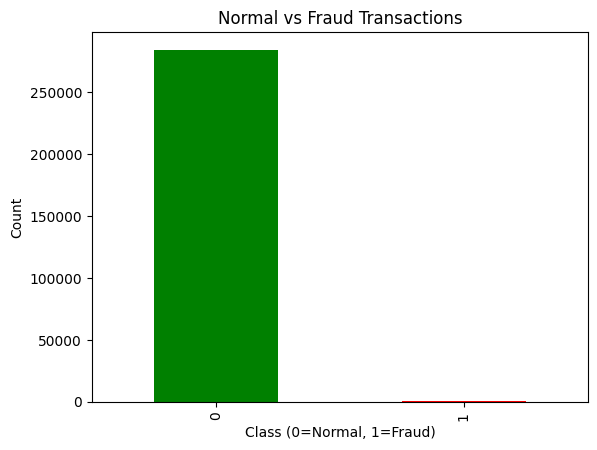

In [12]:
import matplotlib.pyplot as plt

df['Class'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Normal vs Fraud Transactions')
plt.xlabel('Class (0=Normal, 1=Fraud)')
plt.ylabel('Count')
plt.show()

PREPROCESSING(DATA KO SCALE KRNA)


In [18]:
from sklearn.preprocessing import StandardScaler
                               #scaling se column range me aty
scaler = StandardScaler()     #object

df['Amount'] = scaler.fit_transform(df[['Amount']]) #fit means avg liya or scale kr
df['Time'] = scaler.fit_transform(df[['Time']])

FEATURE OR TARGET

In [19]:
X = df.drop('Class', axis=1)
y = df['Class']         #class column jo predict krna hy

TRAIN TEST SPLIT

In [22]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y      #stratify for fraud ka ratio same
)

In [23]:
print("X_train shape:", X_train.shape)      #itna sekhy ga 
print("X_test shape:", X_test.shape)       #itna test kry ga
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (227845, 30)
X_test shape: (56962, 30)
y_train shape: (227845,)
y_test shape: (56962,)


MODEL 1 SVM

In [24]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', random_state=42)    #complex pattern k lye kernel
svm_model.fit(X_train, y_train)


SVC(random_state=42)

PREDICTION

In [27]:
y_pred_svm = svm_model.predict(X_test)

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))   

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.69      0.80        98

    accuracy                           1.00     56962
   macro avg       0.97      0.85      0.90     56962
weighted avg       1.00      1.00      1.00     56962



RNN MODEL

In [29]:
#simple rnn k lye reshape krna pry ga data q k usy 3d data chye phr train or test data ayega

import numpy as np

X_train_rnn = np.array(X_train).reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_rnn = np.array(X_test).reshape(X_test.shape[0], X_test.shape[1], 1)

print(X_train_rnn.shape)
print(X_test_rnn.shape)

(227845, 30, 1)
(56962, 30, 1)


In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

rnn_model = Sequential()
rnn_model.add(SimpleRNN(50, activation='tanh', input_shape=(30, 1)))
rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
rnn_model.summary()

2026-04-26 08:43:54.566646: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777193034.779937      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777193034.840440      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777193035.352958      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777193035.352991      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777193035.352994      55 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

MODEL TRAIN

In [31]:
rnn_model.fit(X_train_rnn, y_train, epochs=5, batch_size=32, validation_split=0.1)

Epoch 1/5


I0000 00:00:1777193206.072356     660 service.cc:152] XLA service 0x793d08027400 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777193206.072401     660 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777193206.072409     660 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777193206.395477     660 cuda_dnn.cc:529] Loaded cuDNN version 91002


  30/6409 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step - accuracy: 0.6415 - loss: 0.6146 

I0000 00:00:1777193207.251458     660 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6409/6409 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step - accuracy: 0.9911 - loss: 0.0295 - val_accuracy: 0.9989 - val_loss: 0.0068
Epoch 2/5
6409/6409 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.9987 - loss: 0.0075 - val_accuracy: 0.9983 - val_loss: 0.0048
Epoch 3/5
6409/6409 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.9990 - loss: 0.0051 - val_accuracy: 0.9992 - val_loss: 0.0052
Epoch 4/5
6409/6409 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.9990 - loss: 0.0056 - val_accuracy: 0.9995 - val_loss: 0.0038
Epoch 5/5
6409/6409 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.9993 - loss: 0.0042 - val_accuracy: 0.9995 - val_loss: 0.0033


PREDICTION


In [32]:
y_pred_rnn = (rnn_model.predict(X_test_rnn) > 0.5).astype(int)
print(classification_report(y_test, y_pred_rnn))

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.76      0.78        98

    accuracy                           1.00     56962
   macro avg       0.91      0.88      0.89     56962
weighted avg       1.00      1.00      1.00     56962



LSTM MODEL

In [33]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='tanh', input_shape=(30, 1)))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
lstm_model.fit(X_train_rnn, y_train, epochs=5, batch_size=32, validation_split=0.1)

Epoch 1/5
6409/6409 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - accuracy: 0.9974 - loss: 0.0216 - val_accuracy: 0.9996 - val_loss: 0.0032
Epoch 2/5
6409/6409 ━━━━━━━━━━━━━━━━━━━━ 36s 6ms/step - accuracy: 0.9993 - loss: 0.0039 - val_accuracy: 0.9994 - val_loss: 0.0033
Epoch 3/5
6409/6409 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step - accuracy: 0.9993 - loss: 0.0039 - val_accuracy: 0.9995 - val_loss: 0.0034
Epoch 4/5
6409/6409 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step - accuracy: 0.9992 - loss: 0.0049 - val_accuracy: 0.9993 - val_loss: 0.0042
Epoch 5/5
6409/6409 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step - accuracy: 0.9992 - loss: 0.0041 - val_accuracy: 0.9995 - val_loss: 0.0028


In [35]:
y_pred_lstm = (lstm_model.predict(X_test_rnn) > 0.5).astype(int)
print(classification_report(y_test, y_pred_lstm))          #model kitny real cases pkr skta is f1 score

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962



GRU MODEL

In [36]:
from tensorflow.keras.layers import GRU

gru_model = Sequential()
gru_model.add(GRU(50, activation='tanh', input_shape=(30, 1)))
gru_model.add(Dense(1, activation='sigmoid'))

gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
gru_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
gru_model.fit(X_train_rnn, y_train, epochs=5, batch_size=32, validation_split=0.1)

Epoch 1/5
6409/6409 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - accuracy: 0.9974 - loss: 0.0226 - val_accuracy: 0.9996 - val_loss: 0.0035
Epoch 2/5
6409/6409 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step - accuracy: 0.9993 - loss: 0.0042 - val_accuracy: 0.9995 - val_loss: 0.0032
Epoch 3/5
6409/6409 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step - accuracy: 0.9993 - loss: 0.0044 - val_accuracy: 0.9993 - val_loss: 0.0039
Epoch 4/5
6409/6409 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - accuracy: 0.9993 - loss: 0.0036 - val_accuracy: 0.9996 - val_loss: 0.0030
Epoch 5/5
6409/6409 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step - accuracy: 0.9994 - loss: 0.0037 - val_accuracy: 0.9995 - val_loss: 0.0029


In [38]:
y_pred_gru = (gru_model.predict(X_test_rnn) > 0.5).astype(int)
print(classification_report(y_test, y_pred_gru))

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.79      0.80        98

    accuracy                           1.00     56962
   macro avg       0.91      0.89      0.90     56962
weighted avg       1.00      1.00      1.00     56962

